# SVI volatility surface, end to end

The objective from this repo is to import one CBOE snapshot, and obtain an arbitrage-free surface. This notebook runs the
whole work step by step and reads the outputs as we go. The machinery lives in
`src/svi/`.

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src" / "svi"))

import numpy as np
import pandas as pd
from IPython.display import Image, display

DATA = ROOT / "data" / "sample" / "spx_quotedata_20260803.csv"
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 120)

## 1. Load the Data

In [2]:
from chain import load_cboe_csv

snap = load_cboe_csv(DATA)
print(f"spot {snap.spot:,.2f}   asof {snap.asof.date()}   "
      f"{len(snap.quotes):,} quotes")
snap.quotes.head(4)

spot 7,489.72   asof 2026-08-03   26,088 quotes


,expiry,strike,root,cp,bid,ask,volume,open_interest,mid,spread,T,k_spot
0,2026-08-03,3000.0,SPXW,C,4514.8,4538.8,0.0,0.0,4526.8,24.0,0.0,-0.914919
1,2026-08-03,3200.0,SPXW,C,4314.8,4338.8,0.0,0.0,4326.8,24.0,0.0,-0.850381
2,2026-08-03,3400.0,SPXW,C,4114.7,4138.7,0.0,0.0,4126.7,24.0,0.0,-0.789756
3,2026-08-03,3600.0,SPXW,C,3914.7,3938.7,1.0,1.0,3926.7,24.0,0.0,-0.732598


The loader turns the CBOE layout (one row per strike, call and put
squashed together) into one row per option, and resolves the SPX/SPXW
duplication by keeping the dominant root per expiry, which is why 14,456
strike rows become 26,088 quotes rather than 28,912. The head already
hints at the cleaning to come: strikes near 1,000 on a 7,490 index, put
bids of zero, call spreads of 20 points. A large share of the raw file is
quotes nobody intends to trade.

## 2. Filter the Raw Data to ensure interpretability

In [3]:
from filter import apply_quote_filters, apply_shape_filters, rejection_log

q = snap.quotes.copy()          # the raw table stays untouched, parity needs it
q["reason"] = ""
apply_quote_filters(q)
apply_shape_filters(q)
rejection_log(q)

,removed,pct
reason,,
in-the-money,11508.0,44.1
maturity < 7d,3072.0,11.8
convexity,1641.0,6.3
spread > 25%,839.0,3.2
zero bid,393.0,1.5
monotonicity,3.0,0.0
KEPT,8632.0,33.1


Reading the log as two different stories. Rows one and two, 56% of the
file, are deliberate selection rather than data quality: the ITM half is
redundant because parity ties each ITM option to its OTM twin, and the
front week has too little variance left to measure. The genuine quality
findings are the other rows: 6.3% of quotes violate convexity (stale
prices at illiquid strikes, mostly deep wings) and 1.5% have no bid at
all. Monotonicity catches almost nothing once convexity has run, which is
expected: a stale quote that breaks one usually breaks the other, and the
first check to see it owns it. What survives is 8,632 quotes across 49
expiries, median 146 per expiry, all of them dense enough to fit.

## 3. Forwards and discounts

In [4]:
from forwards import measure_forwards

fwd = measure_forwards(snap.quotes)
print(f"{len(fwd)} expiries measured   "
      f"r range {fwd.r.min():.2%} to {fwd.r.max():.2%}")
pd.concat([fwd.head(4), fwd.tail(3)]).round({"T": 3, "D": 4, "F": 2, "r": 4})

49 expiries measured   r range 3.93% to 5.79%


,expiry,T,n_pairs,D,F,r
0,2026-08-11,0.022,158,0.9990,7531.50,0.0434
1,2026-08-12,0.025,165,0.9990,7532.15,0.0395
2,2026-08-13,0.027,157,0.9989,7532.85,0.0410
3,2026-08-14,0.030,215,0.9985,7534.44,0.0493
46,2029-12-21,3.384,79,0.8515,8573.81,0.0475
47,2030-12-20,4.381,49,0.8097,8921.15,0.0482
48,2031-12-19,5.377,18,0.7324,8844.32,0.0579


One OLS line per expiry on y = C - P against K recovers D from the slope
and F from the intercept, with no rate or dividend model anywhere. Three
checks pass at a glance. D slides monotonically from 0.999 at one week to
0.73 at five years, exactly the shape a discount curve must have. The
implied rate r sits at 3.9% to 4.8% across almost the whole curve, a
believable money market. And the one week forward prints 7,531.5 against
the header spot of 7,489.7: carry over eight days cannot be 0.55%, so the
gap is the pre-market header being stale, and the regression has told us
where the index actually stood at 05:22. The one row to distrust is the
last: Dec 2031 has only 18 live pairs, its r jumps to 5.8% and its F
breaks the smooth climb, so few points make a wobbly line.

## 4. Implied volatilities

In [5]:
from black76 import invert_chain, twin_check

iv = invert_chain(q, fwd)
bad = int(iv["sigma"].isna().sum())
qs = iv["sigma"].quantile([0, .5, 1])
print(f"{len(iv):,} quotes inverted, {bad} failed roots   "
      f"vol min/median/max {qs.iloc[0]:.1%} / {qs.iloc[1]:.1%} / {qs.iloc[2]:.1%}")
twin_check(snap.quotes, fwd).round(4)

8,632 quotes inverted, 0 failed roots   vol min/median/max 9.0% / 18.5% / 89.2%


,strike,sigma_call,sigma_put,gap_bp
3,7580.0,0.1435,0.1435,0.3150
1,7585.0,0.1431,0.1431,0.3004
0,7590.0,0.1427,0.1427,0.2858
2,7595.0,0.1423,0.1423,-0.0689
4,7600.0,0.1419,0.1419,0.2567


Zero failed roots is not luck: the quotes that would have broken the
bracket (below intrinsic, absurdly high) are the ones the filters already
removed, so clean in means clean out. The vol band runs 9% to 89%, which
is not noise but structure: the low end is long-dated near-the-money calm,
the high end is short-dated deep OTM puts, crash insurance priced dearly.
The twin table is the certificate for section 3: inverting the call door
and the put door at the same strike gives vols agreeing to a third of a
basis point. Parity closes, so F and D are right.

## 5. First pictures 

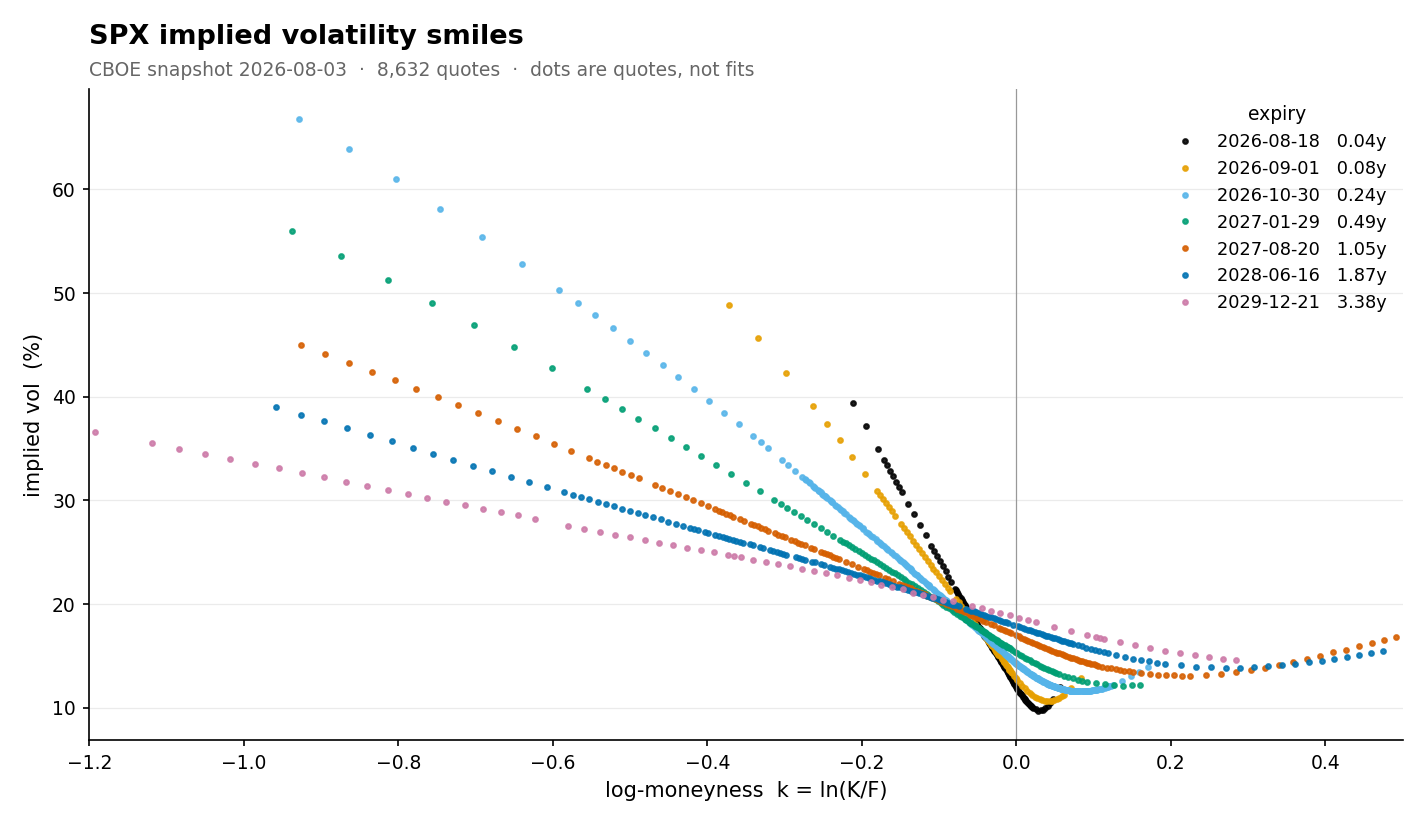

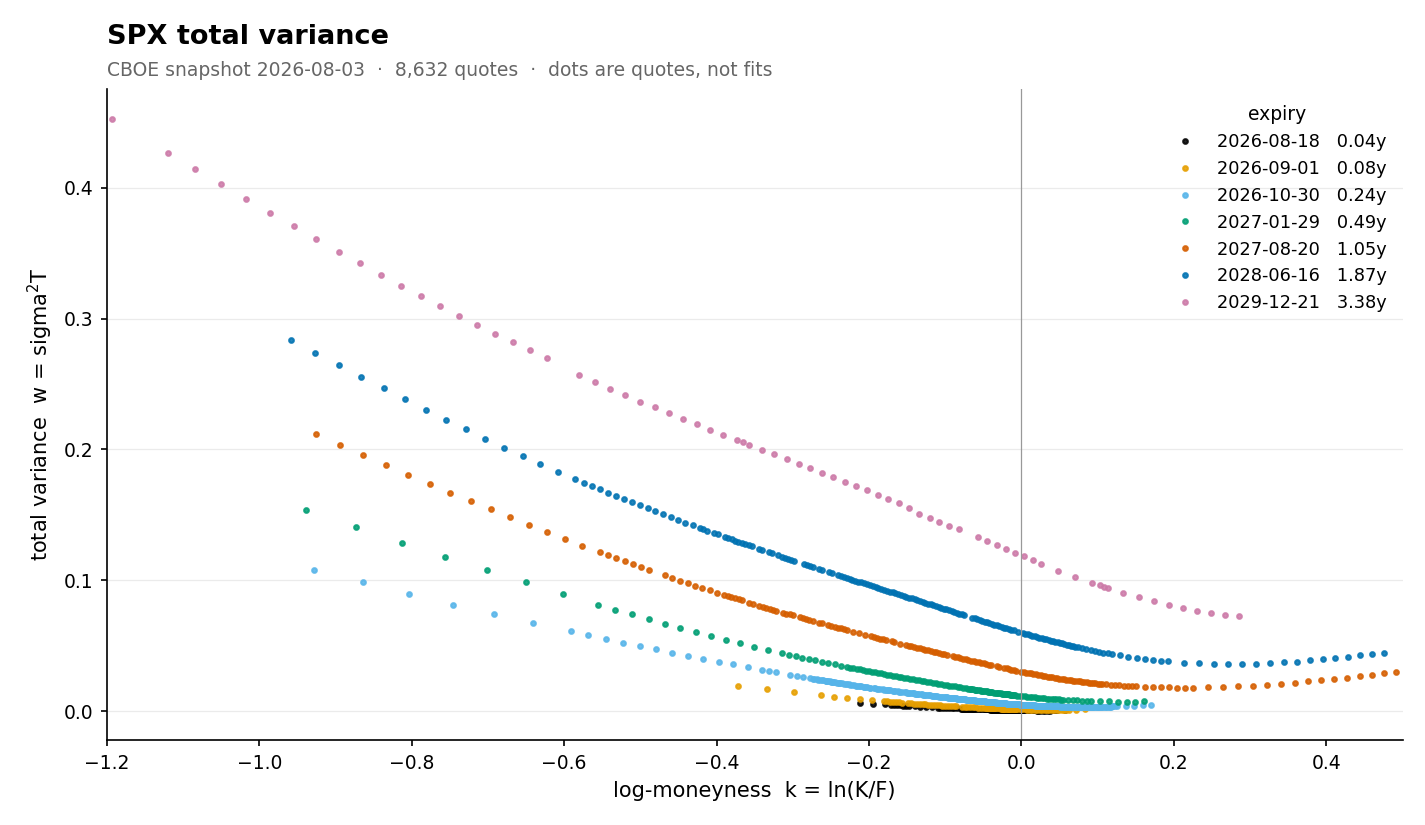

In [6]:
from plots import pick_expiries, plot_smiles, plot_total_variance, plot_fits

ex = pick_expiries(fwd)
sub = f"CBOE snapshot {snap.asof.date()}  ·  {len(iv):,} quotes  ·  dots are quotes, not fits"
plot_smiles(iv, ex, FIG / "smiles.png", sub)
plot_total_variance(iv, ex, FIG / "total_variance.png", sub)
display(Image(FIG / "smiles.png", width=820))
display(Image(FIG / "total_variance.png", width=820))

Four things to read off the smiles. Every curve falls from left to right:
the market charges more implied vol for downside strikes than upside ones,
the equity skew. The curves fan: days-to-weeks maturities plunge through
the money while multi-year ones are gentle lines, so crash fear is
concentrated per unit of time at the front. They pivot around 18% to 20%
near k = 0. And the 1y to 2y curves turn back up on the call wing, so at
long horizons this is a genuine smile, not only a skew. In the second
plot the same data is shown as total variance w = sigma^2 T, and the
curves stack by maturity without crossing anywhere in the shown range.
That stacking is the calendar no-arbitrage condition appearing in raw
data before we impose anything.

## 6. Fitting the SVI

In [7]:
from fit import fit_all

fits = fit_all(iv)
print(f"median rmse {fits.rmse_vol_bp.median():.1f} vol bp   "
      f"rho range [{fits.rho.min():.3f}, {fits.rho.max():.3f}]")
fits.assign(expiry=fits.expiry.dt.date).round(
    {"T": 3, "a": 5, "b": 4, "rho": 3, "m": 3, "s": 4, "rmse_vol_bp": 1})

median rmse 28.1 vol bp   rho range [-0.999, 0.000]


,expiry,T,a,b,rho,m,s,n,rmse_vol_bp
0,2026-08-11,0.022,-0.00260,0.0308,-0.826,-0.113,0.1499,132,18.8
1,2026-08-12,0.025,-0.01539,0.0560,-0.506,-0.132,0.3221,145,27.6
2,2026-08-13,0.027,-0.08671,0.1194,-0.004,0.041,0.7285,135,33.7
3,2026-08-14,0.030,-0.03908,0.0837,-0.000,0.044,0.4704,186,34.7
4,2026-08-17,0.038,-0.04184,0.0868,-0.011,0.044,0.4859,139,27.1
5,2026-08-18,0.041,-0.01323,0.0557,0.000,0.038,0.2452,140,35.4
6,2026-08-19,0.044,-0.01009,0.0518,-0.000,0.036,0.2041,144,37.6
7,2026-08-20,0.047,-0.01507,0.0606,-0.000,0.042,0.2569,132,31.4
8,2026-08-21,0.049,-0.01866,0.0668,0.000,0.045,0.2869,253,25.6
9,2026-08-24,0.057,-0.01668,0.0661,0.000,0.045,0.2613,111,29.9


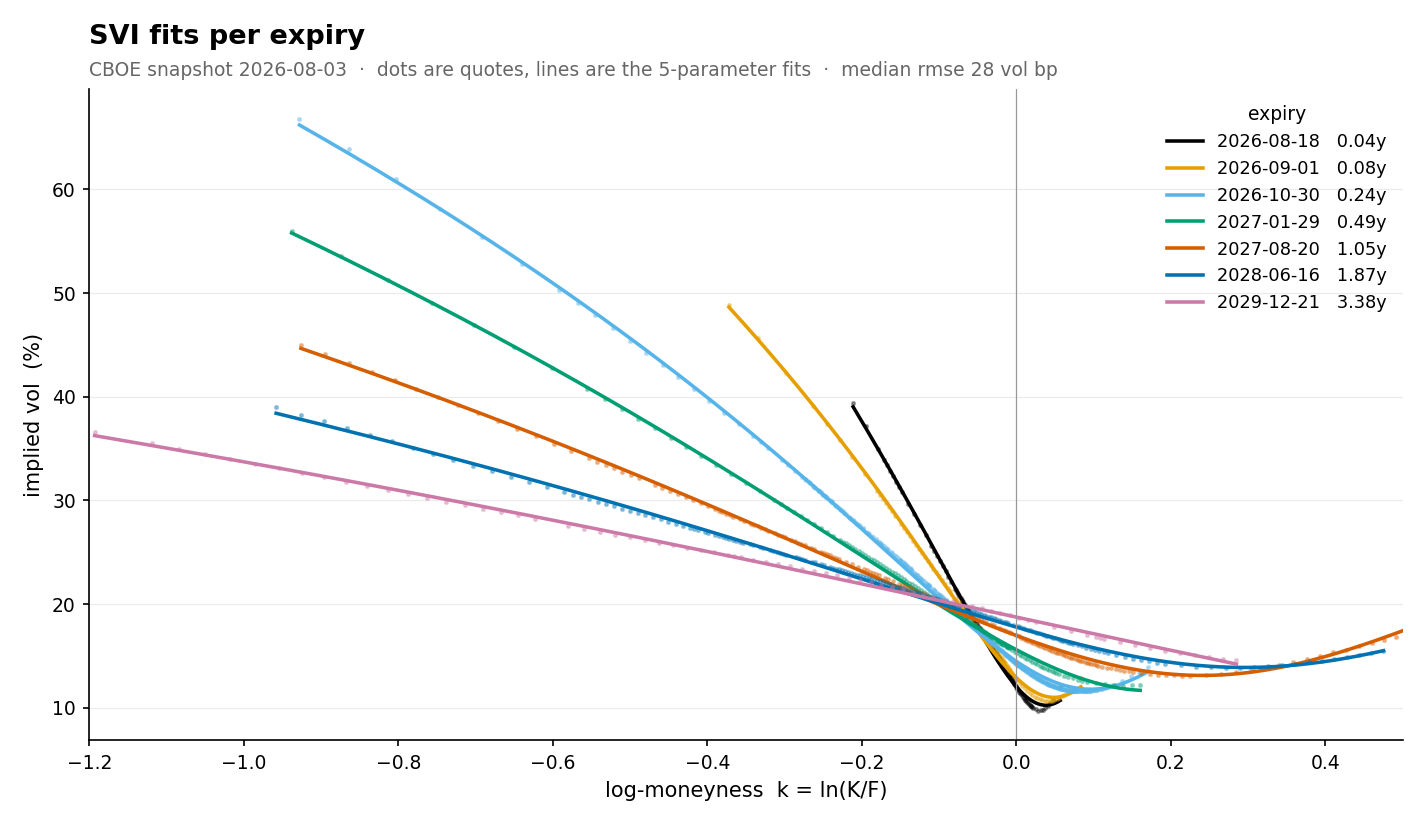

In [8]:
sub = (f"CBOE snapshot {snap.asof.date()}  ·  dots are quotes, lines are "
       f"the 5-parameter fits  ·  median rmse {fits.rmse_vol_bp.median():.0f} vol bp")
plot_fits(iv, fits, ex, FIG / "svi_fits.png", sub)
Image(FIG / "svi_fits.png", width=820)

Median error is 28 volatility basic points, roughly a quarter of a vol point, inside the
bid-ask spreads the quotes came from, chasing much lower would mean
fitting the noise between bid and ask rather than the smile. The
parameter columns deserve a more suspicious read than the figure. Many
rho values sit exactly on a boundary (0 or -0.999) and a is often
negative with s large: with strikes only out to |k| of about 1, several
parameter sets draw nearly the same curve over the quoted range and
differ only in wings the market never priced. So the curve is tightly
identified and the individual dials are not. The fit pins the dials with
stated priors (rho <= 0 for an equity, Lee's wing bound, the elbow boxed
inside the data, the curve's minimum kept non-negative) rather than
pretending the data chose them. The worst rmse (root mean squared error) rows are the shortest
maturities, where a cent of price noise is worth the most volatility.

## 7. Arbitrage-free: we check, then we repair

In [9]:
from surface import butterfly_report, calendar_report, repair_calendar

ranges = {e: (g["k"].min(), g["k"].max()) for e, g in iv.groupby("expiry")}
bf, cal = butterfly_report(fits, ranges), calendar_report(fits, ranges)
print(f"before: butterfly {int((~bf.butterfly_ok).sum())}/{len(bf)}   "
      f"calendar {int((~cal.calendar_ok).sum())}/{len(cal)}")
cal[~cal.calendar_ok].assign(expiry=lambda d: d.expiry.dt.date).round(
    {"T": 3, "vs_T": 3, "min_gap": 5, "at_k": 3})

before: butterfly 0/48   calendar 7/47


,expiry,T,vs_T,min_gap,at_k,calendar_ok
6,2026-08-20,0.047,0.044,-0.00001,0.057,False
11,2026-08-27,0.066,0.063,-0.00002,0.072,False
14,2026-09-01,0.079,0.077,-0.00006,0.084,False
16,2026-09-03,0.085,0.082,-0.00008,0.083,False
18,2026-09-08,0.099,0.088,-0.00004,0.083,False
19,2026-09-09,0.101,0.099,-0.00010,0.045,False
38,2027-06-30,0.906,0.871,-0.00067,0.210,False


In [10]:
fixed, lifts = repair_calendar(fits, ranges)
bf2, cal2 = butterfly_report(fixed, ranges), calendar_report(fixed, ranges)
print(f"after:  butterfly {int((~bf2.butterfly_ok).sum())}/{len(bf2)}   "
      f"calendar {int((~cal2.calendar_ok).sum())}/{len(cal2)}")
if len(lifts):
    print(f"smiles lifted {len(lifts)}, max cost "
          f"{lifts.lift_vol_bp.max():.1f} vol bp at the money")

cols = ["expiry", "T", "n", "a", "b", "rho", "m", "s", "rmse_vol_bp"]
fixed[cols].to_csv(FIG / "svi_params.csv", index=False)
print("wrote figures/svi_params.csv, the arbitrage-free parameter set")

after:  butterfly 0/48   calendar 0/47
smiles lifted 11, max cost 66.7 vol bp at the money
wrote figures/svi_params.csv, the arbitrage-free parameter set


The butterfly condition passes on all 48 smiles with no intervention:
every fitted curve already carries a non-negative implied density. The
calendar condition fails on seven adjacent pairs, and the violation table
is the interesting part: every single crossing sits at the far right edge
of the quoted strike range, the border where data ends and the wings
begin, exactly where the identifiability finding says the curves are
guesswork. Six of the seven are between weekly expiries only days apart,
whose variance levels are so close that fit noise alone crosses them, and
the worst shortfall is 0.0007 in w, whisker thin. The repair lifts the
level dial of a violating smile by exactly its worst shortfall, walking
maturities upward so a fix cannot create a new violation behind it.
Eleven smiles move, the worst by 67 vol bp at the money on a short weekly
where tiny total variance makes any lift expensive in vol terms, and the
surface comes out clean. The cost of legality is small and on record.

## 8. The harvest: implied densities

T=0.08  density mass on quoted range: 0.994
T=0.24  density mass on quoted range: 0.997
T=0.49  density mass on quoted range: 0.971
T=1.05  density mass on quoted range: 0.985


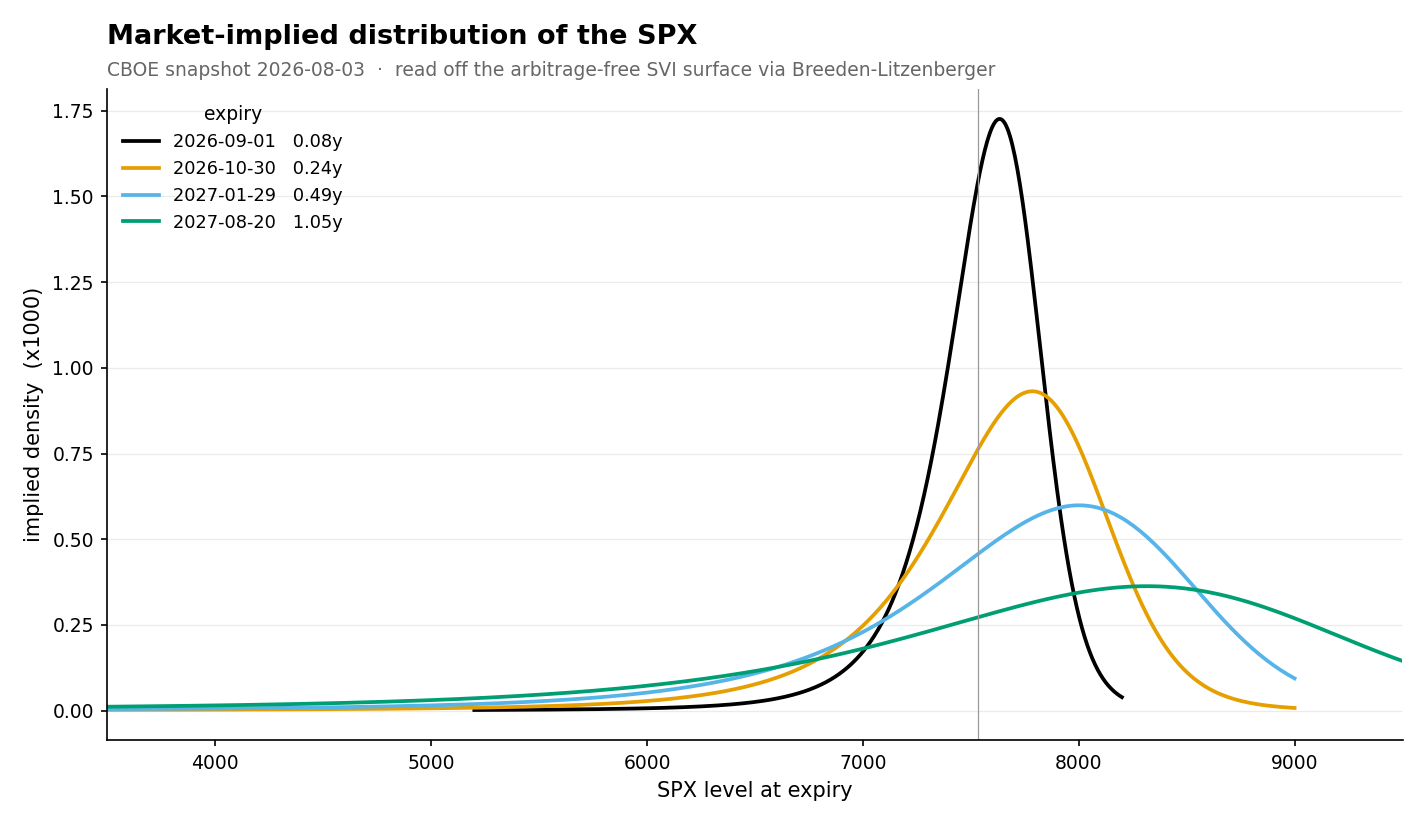

In [11]:
import matplotlib.pyplot as plt
from density import implied_density_k, TARGET_T
from plots import _style, style_of

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, t in enumerate(TARGET_T):
    p = fixed.iloc[(fixed["T"] - t).abs().argmin()]
    F = float(fwd.loc[fwd["expiry"] == p["expiry"], "F"].iloc[0])
    lo, hi = ranges[p["expiry"]]
    k = np.linspace(lo, hi, 600)
    qk = implied_density_k(k, p["a"], p["b"], p["rho"], p["m"], p["s"])
    S = F * np.exp(k)
    ax.plot(S, qk / S * 1000, "-", lw=1.8, color=style_of(i),
            label=f"{p['expiry'].date()}   {p['T']:.2f}y")
    print(f"T={p['T']:.2f}  density mass on quoted range: "
          f"{np.trapezoid(qk, k):.3f}")
ax.axvline(float(fwd["F"].iloc[0]), lw=0.6, color="0.6")
_style(ax, f"CBOE snapshot {snap.asof.date()}  ·  read off the "
           f"arbitrage-free SVI surface via Breeden-Litzenberger")
ax.set_xlim(3500, 9500)
ax.set_xlabel("SPX level at expiry", fontsize=10)
ax.set_ylabel("implied density  (x1000)", fontsize=10)
ax.set_title("Market-implied distribution of the SPX", fontsize=13,
             loc="left", pad=22, weight="bold")
ax.legend(loc="upper left", frameon=False, fontsize=8.5,
          title="expiry", title_fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "implied_density.png", dpi=150)
plt.close(fig)
display(Image(FIG / "implied_density.png", width=820))

These are probability distributions for the index level at four horizons,
read off the surface with no survey and no forecasting model: the second
strike-derivative of call prices is the risk-neutral density, and for SVI
it is built from the same g(k) as the butterfly check, so no-arbitrage
and non-negative probabilities are one statement. Three features carry
the information. The long heavy left tail is the skew translated into
probability, real mass on outcomes 20% to 40% down. The mode sits above
the forward because the risk-neutral mean must equal F while the tail
drags it down, so the most likely outcome is a modest grind up paid for
by a priced-in chance of disaster. And the masses print at 0.97 to 1.00
over just the quoted range with nothing forcing them to, a pipeline-wide
consistency check passing silently. One caveat travels with all of it:
these are risk-neutral densities, so the tail mixes feared probability
with the premium charged for insuring it, and prices alone cannot split
the two.

## Conclusion

In [12]:
from model import svi_w

rows = []
for t in [0.08, 0.25, 0.49, 1.05, 3.38]:
    p = fixed.iloc[(fixed["T"] - t).abs().argmin()]
    atm = np.sqrt(svi_w(0.0, p["a"], p["b"], p["rho"], p["m"], p["s"]) / p["T"])
    lo, _ = ranges[p["expiry"]]
    kk = np.linspace(lo, np.log(0.90), 400)
    p10 = np.trapezoid(implied_density_k(kk, p["a"], p["b"], p["rho"],
                                         p["m"], p["s"]), kk)
    rows.append({"expiry": p["expiry"].date(), "T": round(p["T"], 2),
                 "atm_vol": f"{atm:.1%}", "P(drop > 10%)": f"{p10:.1%}"})
pd.DataFrame(rows)

,expiry,T,atm_vol,P(drop > 10%)
0,2026-09-01,0.08,13.2%,2.2%
1,2026-10-30,0.24,14.5%,8.2%
2,2027-01-29,0.49,15.6%,14.2%
3,2027-08-20,1.05,17.0%,20.8%
4,2029-12-21,3.38,18.7%,30.6%


Two term structures summarise what the surface says. At-the-money vol
rises from 13.2% at one month to 18.8% at three and a half years, so per
year the market prices the near future as calmer than the long run, a
gently upward curve with no imminent-event premium in the front. The
probability of a 10% drop tells the tail story: about 2% within a month,
21% within a year, 31% within three and a half, so crash risk per unit of
time is highest at the short end (2.2% in a month is far more than one
twelfth of 21%) even though the accumulated number grows with horizon.
That is the same asymmetry as the steep short-dated put wings in section
5, now stated in probability units.

What the surface delivers is compression with obligations. 8,632 quotes
became about 240 numbers in `figures/svi_params.csv` that reproduce the
quoted market to 28 vol bp, price any strike at any of 48 maturities, and
carry a non-negative density everywhere, with the seven edge violations
repaired at a recorded cost of at most 67 vol bp. The two limits worth
stating are the ones the data imposed: the parameters are only partially
identified inside |k| of about 1, so the wings are stated priors rather
than estimates, and the densities are risk-neutral, so they embed
premia and are not pure forecasts. Both limits are properties of what a
single option snapshot can know, not of the code.